In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [27]:
df = pd.read_excel("rajasthan_mustard_clean.xlsx")


: 

In [6]:
df.isnull().sum()

District                               0
Crop                                   0
Season                                 0
Area (hectares)                        0
Yield (quintals)                       0
Production (metric tons)               0
Soil Type                              0
pH Level                               0
Organic Matter (%)                     0
Nitrogen Content (kg/ha)               0
Phosphorus Content (kg/ha)             0
Potassium Content (kg/ha)              0
Irrigation Method                      0
Water Consumption (liters/hectare)     0
Water Availability (liters/hectare)    0
temp                                   0
rain                                   0
humidity                               0
wind_speed                             0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   District                             25000 non-null  object 
 1   Crop                                 25000 non-null  object 
 2   Season                               25000 non-null  object 
 3   Area (hectares)                      25000 non-null  float64
 4   Yield (quintals)                     25000 non-null  float64
 5   Production (metric tons)             25000 non-null  float64
 6   Soil Type                            25000 non-null  object 
 7   pH Level                             25000 non-null  float64
 8   Organic Matter (%)                   25000 non-null  float64
 9   Nitrogen Content (kg/ha)             25000 non-null  float64
 10  Phosphorus Content (kg/ha)           25000 non-null  float64
 11  Potassium Content (kg/ha)   

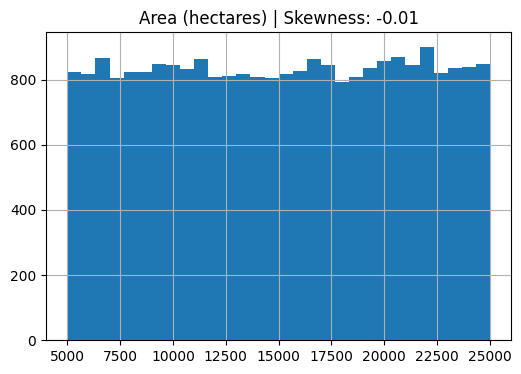

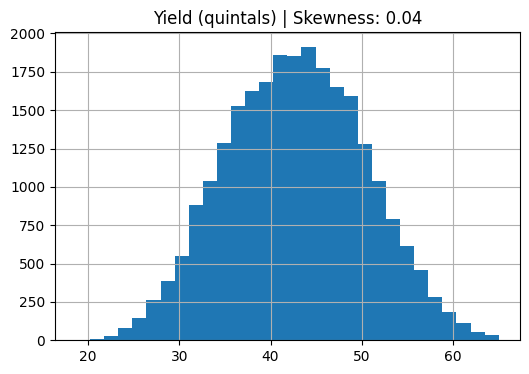

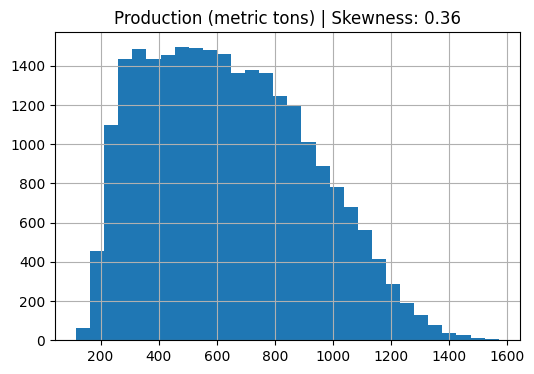

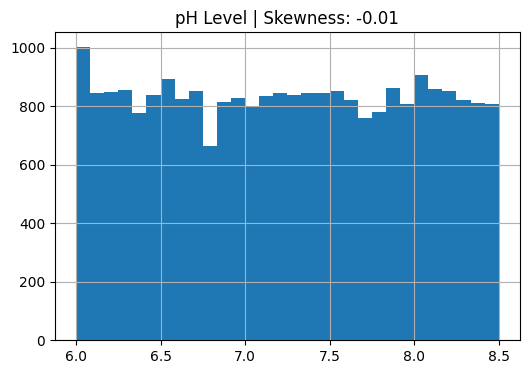

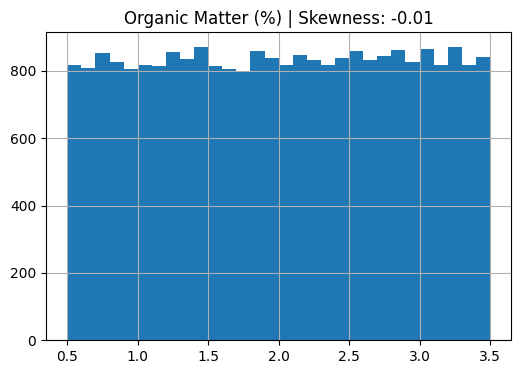

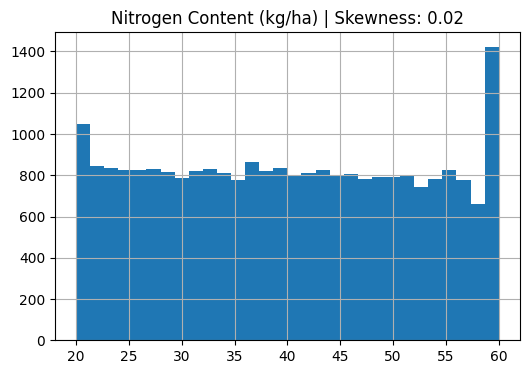

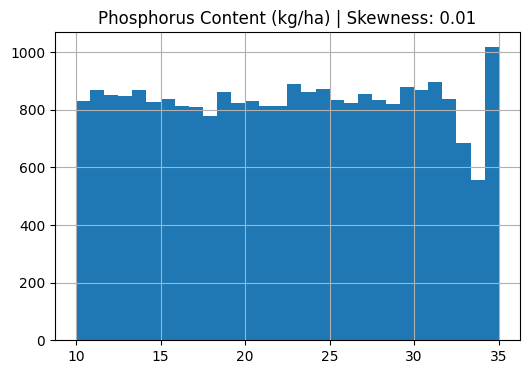

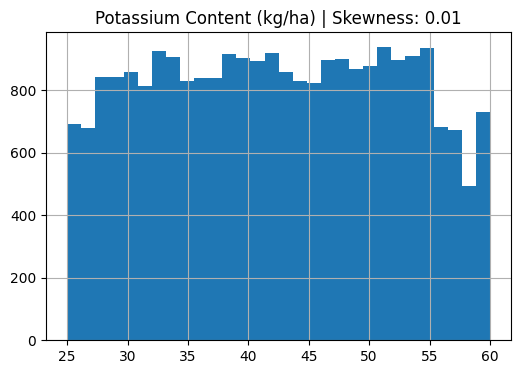

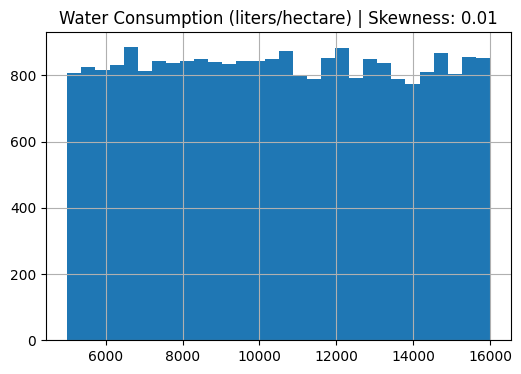

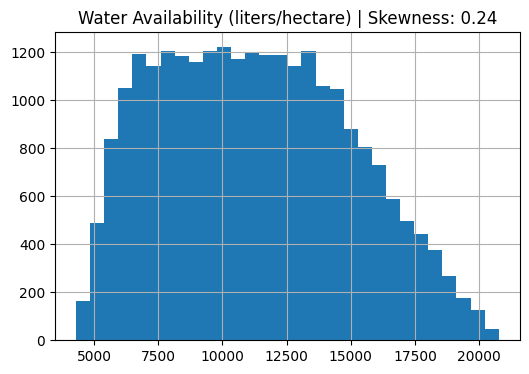

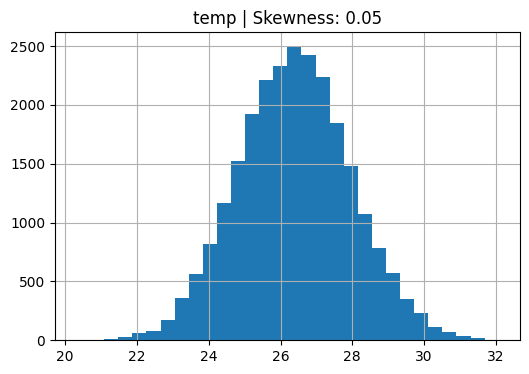

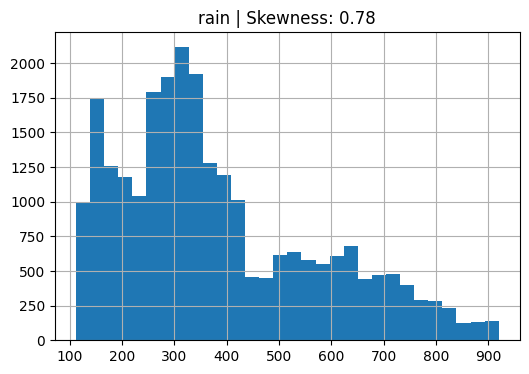

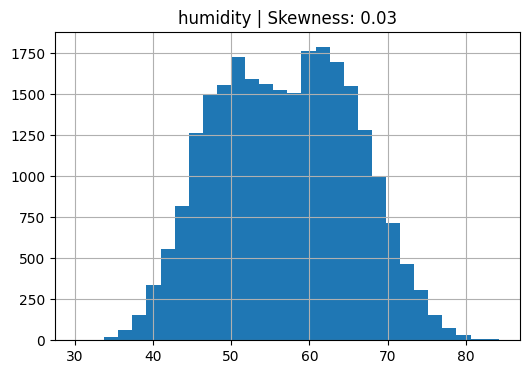

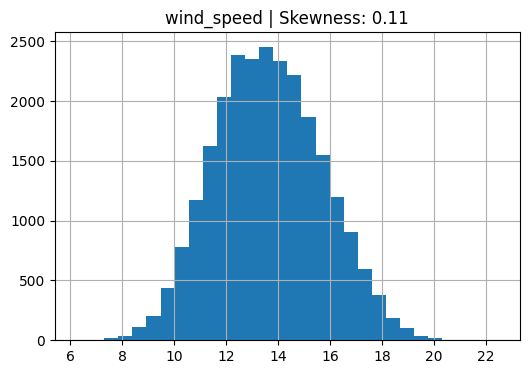

In [8]:

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f'{col} | Skewness: {df[col].skew():.2f}')
    plt.show()

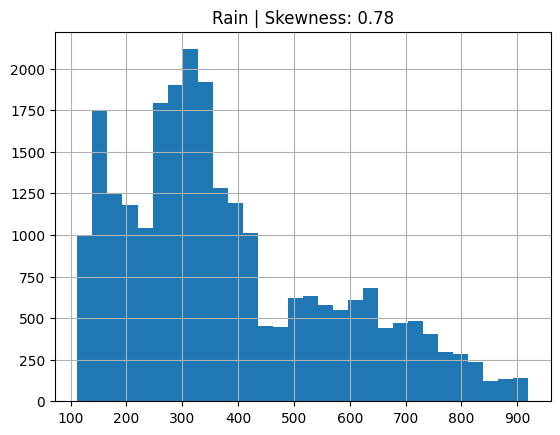

In [9]:
df['rain'].hist(bins=30)
plt.title(f'Rain | Skewness: {df["rain"].skew():.2f}')
plt.show()

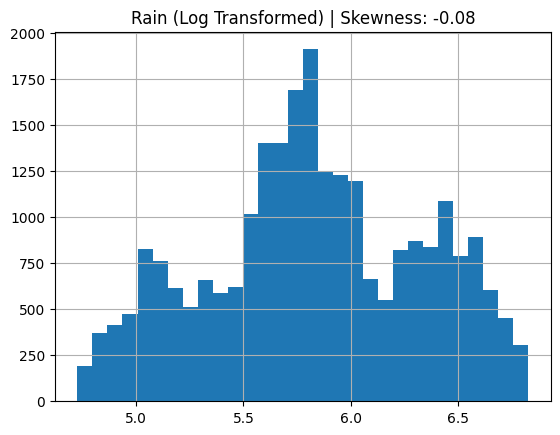

In [28]:
df['rain_log'] = np.log1p(df['rain'])

df['rain_log'].hist(bins=30)
plt.title(f'Rain (Log Transformed) | Skewness: {df["rain_log"].skew():.2f}')
plt.show()
df.drop (columns=['rain'],inplace=True)

In [11]:
# numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# for col in numerical_cols:
#     plt.figure(figsize=(6, 4))
#     df.boxplot(column=col)
#     plt.title(col)
#     plt.show()

In [12]:
df_clean = df.copy()

outlier_cols = [c for c in df_clean.select_dtypes(include=np.number).columns if c != 'Yield (quintals)']

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

print("Before:", df.shape)
print("After:", df_clean.shape)
# Removing outliers in Production, temp, wind_speed is actually removing real data — Rajasthan 
# has extreme summers (45°C+), droughts, unusual wind patterns. 
# These extreme conditions and their effect on yield are valuable signals for the model.

Before: (25000, 19)
After: (24726, 19)


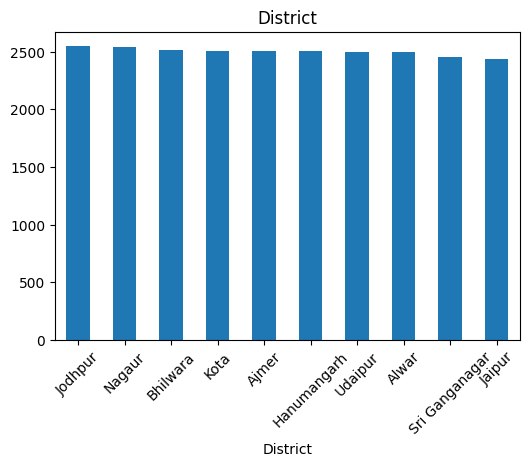

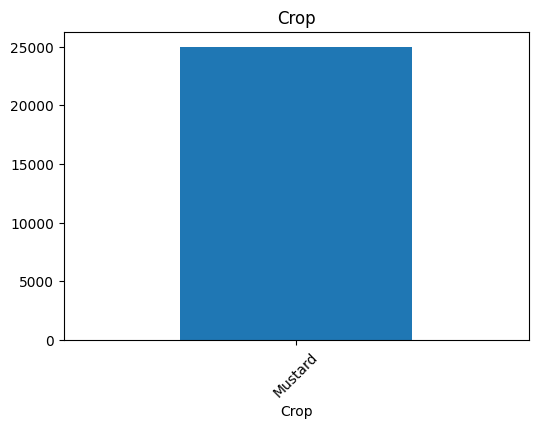

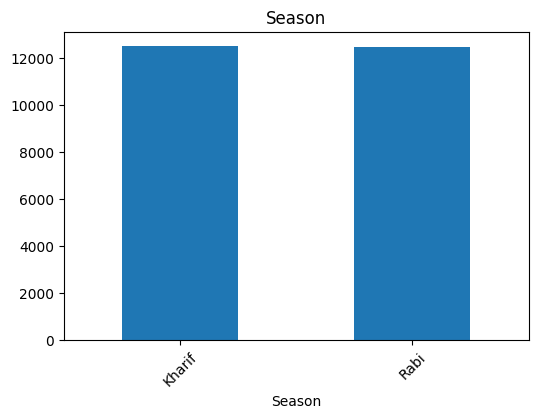

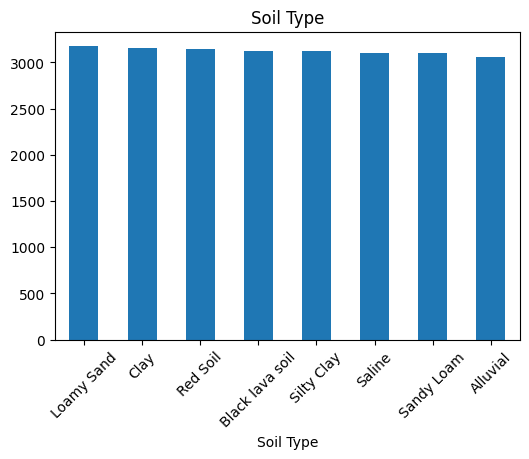

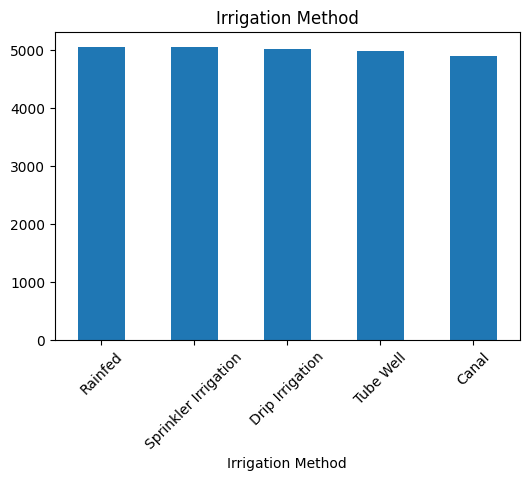

In [13]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

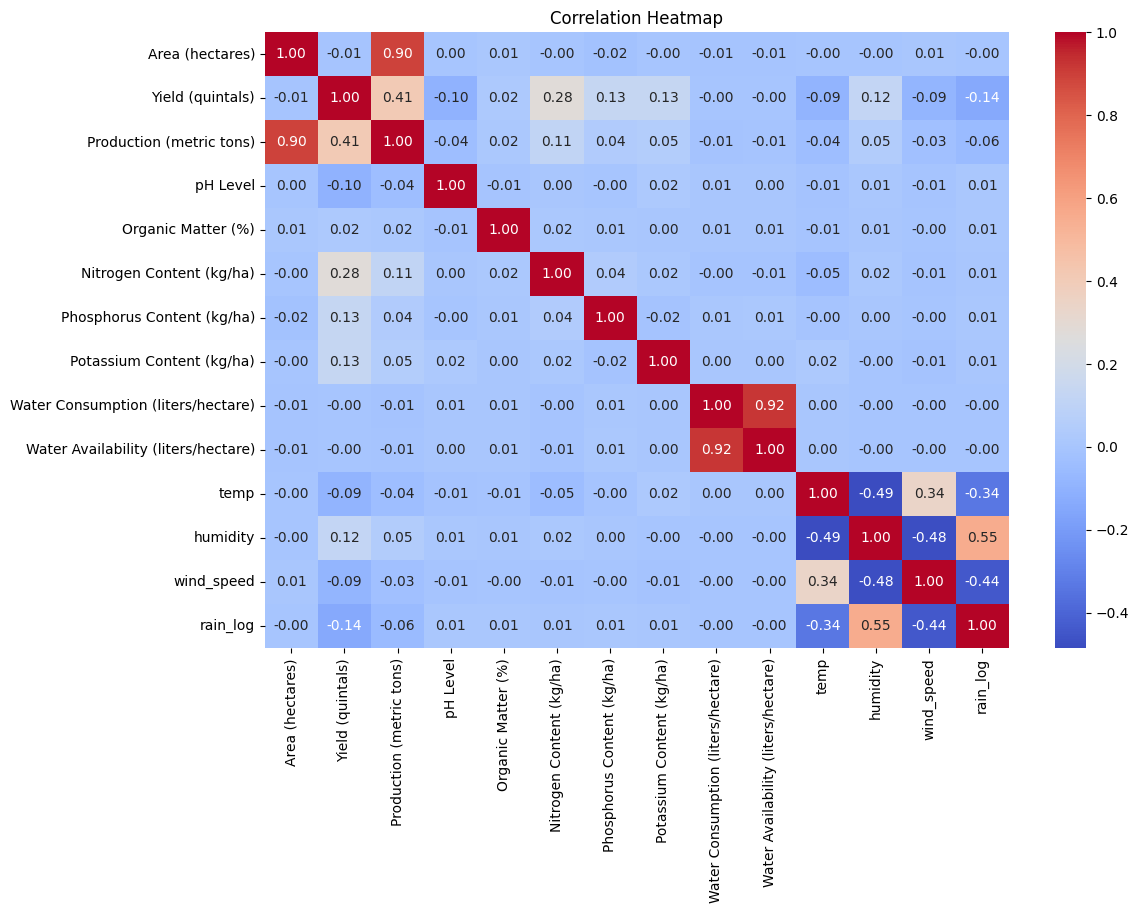

In [14]:
numerical_df = df.select_dtypes(include=np.number)

# heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [15]:
numerical_df.corr()['Yield (quintals)'].sort_values(ascending=False)


Yield (quintals)                       1.000000
Production (metric tons)               0.411807
Nitrogen Content (kg/ha)               0.275356
Potassium Content (kg/ha)              0.133643
Phosphorus Content (kg/ha)             0.132687
humidity                               0.122199
Organic Matter (%)                     0.020707
Water Availability (liters/hectare)   -0.001043
Water Consumption (liters/hectare)    -0.003431
Area (hectares)                       -0.005137
wind_speed                            -0.087345
temp                                  -0.094954
pH Level                              -0.098437
rain_log                              -0.138906
Name: Yield (quintals), dtype: float64

In [ ]:
# Correlation Analysis with Target (Yield):
# - Production (0.41) and Nitrogen (0.25) show moderate linear correlation
# - Most other features have very low correlation (< 0.11)
# - Many features have near zero or negative correlation
#
# This tells us:
# - There is NO strong linear relationship between features and yield
# - A linear model (Linear Regression) would perform POORLY here
# - The relationships are likely NON-LINEAR and complex
#
# Therefore we should use tree based models which can capture non-linear relationships:
# - Random Forest
# - XGBoost / LightGBM / CatBoost
# - Decision Tree
#
# These models don't rely on linear correlation, they find complex split patterns
# which is exactly what this data needs

: 

: 

: 

: 

: 

In [16]:
corr_matrix = numerical_df.corr().abs()

# get upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# print highly correlated pairs
threshold = 0.8
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > threshold]

for feat1, feat2, corr in high_corr:
    print(f"{feat1} & {feat2} => {corr:.2f}")

Production (metric tons) & Area (hectares) => 0.90
Water Availability (liters/hectare) & Water Consumption (liters/hectare) => 0.92


In [29]:
df['water_efficiency'] = df['Water Availability (liters/hectare)'] / df['Water Consumption (liters/hectare)']

# then drop the original two
df.drop(columns=['Water Availability (liters/hectare)', 'Water Consumption (liters/hectare)'], inplace=True)

In [30]:
df.drop(columns=['Area (hectares)'], inplace=True)

In [19]:
from sklearn.feature_selection import mutual_info_regression

X = df.select_dtypes(include=np.number).drop(columns=['Yield (quintals)'])
y = df['Yield (quintals)']

mi = mutual_info_regression(X, y)

mi_df = pd.DataFrame({'Feature': X.columns, 'Information Gain': mi})
mi_df = mi_df.sort_values('Information Gain', ascending=False)
print(mi_df)

                       Feature  Information Gain
0     Production (metric tons)          0.231725
3     Nitrogen Content (kg/ha)          0.043787
1                     pH Level          0.024271
9                     rain_log          0.017521
5    Potassium Content (kg/ha)          0.014492
6                         temp          0.009199
7                     humidity          0.004454
4   Phosphorus Content (kg/ha)          0.002346
8                   wind_speed          0.001775
2           Organic Matter (%)          0.000000
10            water_efficiency          0.000000


In [35]:
# Fixed feature transformation + MI validation (best formulas selected)
from sklearn.feature_selection import mutual_info_regression

# MI before feature transformation
X_before = df.select_dtypes(include=np.number).drop(columns=['Yield (quintals)'])
y = df['Yield (quintals)']

mi_before = mutual_info_regression(X_before, y, random_state=42)
mi_before_df = pd.DataFrame({
    'Feature': X_before.columns,
    'MI_before': mi_before
}).sort_values('MI_before', ascending=False)
mi_before_map = dict(zip(mi_before_df['Feature'], mi_before_df['MI_before']))

# Best fixed formulas chosen from prior search
parent_npk_cols = [
    'Nitrogen Content (kg/ha)',
    'Phosphorus Content (kg/ha)',
    'Potassium Content (kg/ha)'
]
parent_weather_cols = ['temp', 'humidity']
has_npk_parents = all(col in df.columns for col in parent_npk_cols)
has_ph_parent = 'pH Level' in df.columns
has_weather_parents = all(col in df.columns for col in parent_weather_cols)

if has_npk_parents:
    df['nutrient_index'] = (
        df['Nitrogen Content (kg/ha)']
        + df['Phosphorus Content (kg/ha)']
        + df['Potassium Content (kg/ha)']
    )
if has_ph_parent:
    df['ph_suitability'] = np.exp(-((df['pH Level'] - 6.6) ** 2) / (2 * (1.2 ** 2)))
if has_weather_parents:
    df['evap_demand_proxy'] = df['temp'] - df['humidity']

# MI after feature transformation
X_after = df.select_dtypes(include=np.number).drop(columns=['Yield (quintals)'])
mi_after = mutual_info_regression(X_after, y, random_state=42)
mi_after_df = pd.DataFrame({
    'Feature': X_after.columns,
    'MI_after': mi_after
}).sort_values('MI_after', ascending=False)
mi_after_map = dict(zip(mi_after_df['Feature'], mi_after_df['MI_after']))

# Compare engineered feature MI against parent-feature average MI
comparison = pd.DataFrame([
    {
        'Engineered Feature': 'nutrient_index',
        'Parent Avg MI (before)': np.mean([
            mi_before_map.get('Nitrogen Content (kg/ha)', 0),
            mi_before_map.get('Phosphorus Content (kg/ha)', 0),
            mi_before_map.get('Potassium Content (kg/ha)', 0)
        ]),
        'Engineered MI (after)': mi_after_map.get('nutrient_index', 0)
    },
    {
        'Engineered Feature': 'ph_suitability',
        'Parent Avg MI (before)': mi_before_map.get('pH Level', 0),
        'Engineered MI (after)': mi_after_map.get('ph_suitability', 0)
    },
    {
        'Engineered Feature': 'evap_demand_proxy',
        'Parent Avg MI (before)': np.mean([
            mi_before_map.get('temp', 0),
            mi_before_map.get('humidity', 0)
        ]),
        'Engineered MI (after)': mi_after_map.get('evap_demand_proxy', 0)
    }
])
comparison['Delta'] = comparison['Engineered MI (after)'] - comparison['Parent Avg MI (before)']
comparison = comparison.sort_values('Delta', ascending=False)

print('Fixed engineered formulas in use:')
print('  nutrient_index = N + P + K')
print('  ph_suitability = exp(-((pH - 6.6)^2) / (2 * 1.2^2))')
print('  evap_demand_proxy = temp - humidity')
if not (has_npk_parents and has_ph_parent and has_weather_parents):
    print('Note: Parent columns were already dropped in this session; existing engineered columns were reused where available.')

print('\nTop MI features before transformation:')
print(mi_before_df.head(10).to_string(index=False))
print('\nTop MI features after transformation:')
print(mi_after_df.head(10).to_string(index=False))
print('\nEngineered feature MI improvement:')
print(comparison.round(5).to_string(index=False))

# Keep transformed features and drop their parent columns for a cleaner final dataset
df.drop(columns=[
    'Nitrogen Content (kg/ha)',
    'Phosphorus Content (kg/ha)',
    'Potassium Content (kg/ha)',
    'pH Level',
    'temp',
    'humidity'
], inplace=True, errors='ignore')

Fixed engineered formulas in use:
  nutrient_index = N + P + K
  ph_suitability = exp(-((pH - 6.6)^2) / (2 * 1.2^2))
  evap_demand_proxy = temp - humidity
Note: Parent columns were already dropped in this session; existing engineered columns were reused where available.

Top MI features before transformation:
                 Feature  MI_before
Production (metric tons)   0.231730
          nutrient_index   0.068806
          ph_suitability   0.025692
                rain_log   0.017542
       evap_demand_proxy   0.016691
              wind_speed   0.002037
      Organic Matter (%)   0.000000
        water_efficiency   0.000000

Top MI features after transformation:
                 Feature  MI_after
Production (metric tons)  0.231730
          nutrient_index  0.068806
          ph_suitability  0.025692
                rain_log  0.017542
       evap_demand_proxy  0.016691
              wind_speed  0.002037
      Organic Matter (%)  0.000000
        water_efficiency  0.000000

Engineered

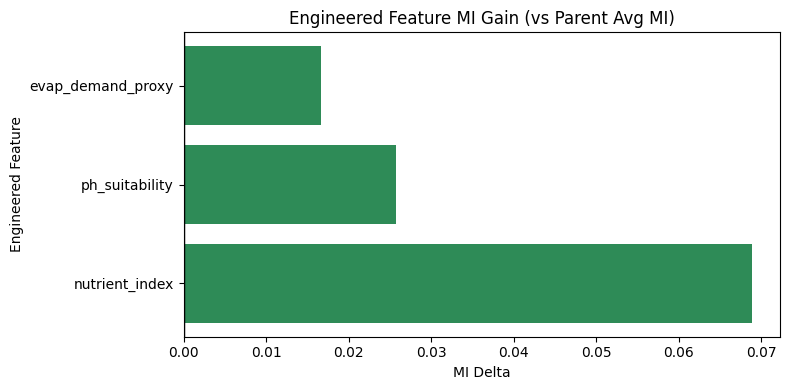

Engineered feature MI summary:
Engineered Feature  Parent Avg MI (before)  Engineered MI (after)   Delta
    nutrient_index                     0.0                0.06881 0.06881
    ph_suitability                     0.0                0.02569 0.02569
 evap_demand_proxy                     0.0                0.01669 0.01669


In [36]:
# Information Gain visualization
plt.figure(figsize=(8, 4))
plot_comp = comparison.copy()
colors = ['seagreen' if d > 0 else 'indianred' for d in plot_comp['Delta']]
plt.barh(plot_comp['Engineered Feature'], plot_comp['Delta'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Engineered Feature MI Gain (vs Parent Avg MI)')
plt.xlabel('MI Delta')
plt.ylabel('Engineered Feature')
plt.tight_layout()
plt.show()

print('Engineered feature MI summary:')
print(comparison.round(5).to_string(index=False))

In [37]:
df.drop(columns=['water_efficiency', 'Organic Matter (%)'], inplace=True)


In [38]:
df.head()

,District,Crop,Season,Yield (quintals),Production (metric tons),Soil Type,Irrigation Method,wind_speed,rain_log,nutrient_index,ph_suitability,evap_demand_proxy
0,Bhilwara,Mustard,Rabi,51.4408,892.4797,Red Soil,Sprinkler Irrigation,14.87,5.490878,130.805730,0.945361,-37.943490
1,Udaipur,Mustard,Kharif,38.8133,722.1668,Saline,Drip Irrigation,11.04,6.414229,125.816854,0.695323,-38.839399
2,Kota,Mustard,Rabi,44.0401,594.6793,Loamy Sand,Sprinkler Irrigation,10.27,5.959793,105.193157,0.490807,-38.985260
3,Kota,Mustard,Rabi,48.9056,1055.1256,Red Soil,Sprinkler Irrigation,10.44,6.046047,90.280255,0.996698,-37.835860
4,Hanumangarh,Mustard,Kharif,27.1306,496.9904,Saline,Canal,14.24,5.773340,91.496300,0.445921,-25.750000


In [39]:
numerical_cols = df.select_dtypes(include=np.number).drop(columns=['Yield (quintals)']).columns



# print range summary
range_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Min': df[numerical_cols].min().values,
    'Max': df[numerical_cols].max().values,
    'Range': (df[numerical_cols].max() - df[numerical_cols].min()).values
})
print(range_df.sort_values('Range', ascending=False).to_string(index=False))

                 Feature        Min         Max       Range
Production (metric tons) 115.358000 1570.561700 1455.203700
          nutrient_index  55.000000  155.000000  100.000000
       evap_demand_proxy -59.400000   -2.300000   57.100000
              wind_speed   6.220000   22.500000   16.280000
                rain_log   4.727830    6.825351    2.097521
          ph_suitability   0.285512    1.000000    0.714488


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Production (metric tons)'] = scaler.fit_transform(df[['Production (metric tons)']])

In [41]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")
    print()

District: ['Bhilwara' 'Udaipur' 'Kota' 'Hanumangarh' 'Alwar' 'Jaipur' 'Ajmer'
 'Jodhpur' 'Nagaur' 'Sri Ganganagar']

Crop: ['Mustard']

Season: ['Rabi' 'Kharif']

Soil Type: ['Red Soil' 'Saline' 'Loamy Sand' 'Black lava soil' 'Alluvial' 'Clay'
 'Sandy Loam' 'Silty Clay']

Irrigation Method: ['Sprinkler Irrigation' 'Drip Irrigation' 'Canal' 'Tube Well' 'Rainfed']



In [42]:
from sklearn.preprocessing import LabelEncoder
import pickle

# drop Crop - only one value
df.drop(columns=['Crop'], inplace=True)

# Keep a CatBoost-friendly copy with the same final columns but original string categories.
# This lets the tuned CatBoost model use native categorical splits without changing the feature set.
df_catboost = df.copy()

# Soil Type has 8 categories, no ordinal relationship
# for trees, label encoding is fine (trees don't assume any order)
# label encode all categorical columns and save encoders
label_encoders = {}

for col in ['Season', 'Soil Type', 'Irrigation Method', 'District']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Season: {'Kharif': np.int64(0), 'Rabi': np.int64(1)}
Soil Type: {'Alluvial': np.int64(0), 'Black lava soil': np.int64(1), 'Clay': np.int64(2), 'Loamy Sand': np.int64(3), 'Red Soil': np.int64(4), 'Saline': np.int64(5), 'Sandy Loam': np.int64(6), 'Silty Clay': np.int64(7)}
Irrigation Method: {'Canal': np.int64(0), 'Drip Irrigation': np.int64(1), 'Rainfed': np.int64(2), 'Sprinkler Irrigation': np.int64(3), 'Tube Well': np.int64(4)}
District: {'Ajmer': np.int64(0), 'Alwar': np.int64(1), 'Bhilwara': np.int64(2), 'Hanumangarh': np.int64(3), 'Jaipur': np.int64(4), 'Jodhpur': np.int64(5), 'Kota': np.int64(6), 'Nagaur': np.int64(7), 'Sri Ganganagar': np.int64(8), 'Udaipur': np.int64(9)}


In [43]:
df.head()

,District,Season,Yield (quintals),Production (metric tons),Soil Type,Irrigation Method,wind_speed,rain_log,nutrient_index,ph_suitability,evap_demand_proxy
0,2,1,51.4408,0.901214,4,3,14.87,5.490878,130.805730,0.945361,-37.943490
1,9,0,38.8133,0.284760,5,1,11.04,6.414229,125.816854,0.695323,-38.839399
2,6,1,44.0401,-0.176686,3,3,10.27,5.959793,105.193157,0.490807,-38.985260
3,6,1,48.9056,1.489917,4,3,10.44,6.046047,90.280255,0.996698,-37.835860
4,3,0,27.1306,-0.530275,5,0,14.24,5.773340,91.496300,0.445921,-25.750000


In [ ]:
# 1. CORRELATION ANALYSIS
# - Low linear correlation with target
# - Suggests NON-LINEAR relationships
# - Rules out: Linear Regression, Logistic Regression
# - Points to: Tree based models

# 2. INFORMATION GAIN (Mutual Information)
# - Domain-driven engineered features were validated with MI delta vs parent variables
# - Selected engineered features with positive delta:
#   nutrient_index, evap_demand_proxy, ph_suitability
# - This provides interpretable agronomic signals and reduces weak/redundant raw weather/soil inputs
# - Strongly supports ensemble trees that can capture interactions

# 3. OUTLIERS
# - Data had significant outliers in Production, temp, wind_speed
# - Models sensitive to outliers would struggle
# - Rules out: Linear Regression, KNN, SVM
# - Points to: Tree based models (outlier resistant)

# 4. FEATURE SCALE DIFFERENCE
# - Production scale is much larger than many climate indicators
# - Scale-sensitive models would need careful normalization
# - Rules out: KNN, SVM, Neural Networks (without robust scaling)
# - Points to: Tree based models (scale invariant)

# 5. DATASET SIZE
# - 25000 rows, compact feature set after selection
# - Medium sized dataset
# - Rules out: Deep Learning (likely unnecessary)
# - Points to: RandomForest / XGBoost / LightGBM as practical choices

: 

: 

: 

: 

: 

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Yield (quintals)'])
y = df['Yield (quintals)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CatBoost path keeps the same columns and engineered features, but preserves raw categoricals.
X_cb = df_catboost.drop(columns=['Yield (quintals)'])
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(X_cb, y, test_size=0.2, random_state=42)
cat_cols = ['District', 'Season', 'Soil Type', 'Irrigation Method']

In [45]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import shap

In [46]:
# Step 1: train all models with default-ish parameters
models = {
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(
        random_seed=42,
        verbose=0,
        loss_function='RMSE',
        allow_writing_files=False
    ),
    'HistGBR': HistGradientBoostingRegressor(random_state=42)
}

In [47]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        'R2': r2_score(y_te, preds),
        'MAE': mean_absolute_error(y_te, preds),
        'RMSE': np.sqrt(mean_squared_error(y_te, preds)),
        'preds': preds
    }

In [48]:
# Step 2: benchmark defaults and select top-1 model
default_results = []
trained_default_models = {}

for name, model in models.items():
    metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
    trained_default_models[name] = model
    default_results.append({
        'Model': name,
        'R2': metrics['R2'],
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE']
    })

default_summary_df = pd.DataFrame(default_results).sort_values('R2', ascending=False).reset_index(drop=True)
print('=== Default Model Benchmark ===')
print(default_summary_df.round(4).to_string(index=False))

best_default_name = default_summary_df.loc[0, 'Model']
best_default_model = trained_default_models[best_default_name]
print(f"\nSelected model for tuning: {best_default_name}")

=== Default Model Benchmark ===
       Model     R2    MAE   RMSE
    CatBoost 0.9699 1.0595 1.3241
    LightGBM 0.9663 1.1190 1.4003
     HistGBR 0.9660 1.1228 1.4055
     XGBoost 0.9612 1.2003 1.5019
RandomForest 0.9558 1.2713 1.6040

Selected model for tuning: CatBoost


In [49]:
# Step 3: one hyperparameter search space based on selected top model (speed-optimized)
param_space_map = {
    'XGBoost': {
        'n_estimators': [300, 500, 700, 900],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.08],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'reg_lambda': [0.5, 1.0, 2.0]
    },
    'LightGBM': {
        'n_estimators': [300, 500, 700, 900],
        'num_leaves': [31, 63, 127],
        'max_depth': [-1, 6, 8, 10],
        'learning_rate': [0.01, 0.03, 0.05, 0.08],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'min_child_samples': [10, 20, 40]
    },
    'CatBoost': {
        'iterations': [800, 1200, 1600],
        'depth': [6, 8],
        'learning_rate': [0.02, 0.03, 0.05],
        'l2_leaf_reg': [3, 5, 7],
        'bagging_temperature': [0.0, 0.3],
        'random_strength': [0.5, 1.0],
        'bootstrap_type': ['Bayesian', 'Bernoulli'],
        'rsm': [0.8, 1.0],
        'boosting_type': ['Ordered']
    },
    'RandomForest': {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [None, 8, 12, 16, 20],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2', 0.8]
    },
    'HistGBR': {
        'max_iter': [300, 500, 800],
        'learning_rate': [0.01, 0.03, 0.05, 0.08],
        'max_depth': [None, 6, 8, 10],
        'min_samples_leaf': [10, 20, 40],
        'l2_regularization': [0.0, 0.1, 1.0]
    }
}

param_grid = param_space_map[best_default_name]
print(f"Tuning search space selected for: {best_default_name}")

Tuning search space selected for: CatBoost


In [50]:
# Step 4: faster RandomizedSearchCV on selected top model
random_search = RandomizedSearchCV(
    estimator=best_default_model,
    param_distributions=param_grid,
    n_iter=12,
    cv=2,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
fit_kwargs = {'cat_features': cat_cols} if best_default_name == 'CatBoost' else {}
search_X = X_train_cb if best_default_name == 'CatBoost' else X_train
search_y = y_train_cb if best_default_name == 'CatBoost' else y_train

random_search.fit(search_X, search_y, **fit_kwargs)

cv_results_df = pd.DataFrame(random_search.cv_results_).sort_values('mean_test_score', ascending=False).reset_index(drop=True)
print('Best Params:', random_search.best_params_)

Fitting 2 folds for each of 12 candidates, totalling 24 fits
Best Params: {'rsm': 1.0, 'random_strength': 1.0, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 1600, 'depth': 8, 'bootstrap_type': 'Bayesian', 'boosting_type': 'Ordered', 'bagging_temperature': 0.3}


In [51]:
# Step 5: evaluate tuned final model
best_model = random_search.best_estimator_
eval_X = X_test_cb if best_default_name == 'CatBoost' else X_test
eval_y = y_test_cb if best_default_name == 'CatBoost' else y_test
y_pred_best = best_model.predict(eval_X)

best_r2 = r2_score(eval_y, y_pred_best)
best_mae = mean_absolute_error(eval_y, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(eval_y, y_pred_best))

print(f"Final Model: {best_default_name} (tuned)")
print(f"Best CV R2: {random_search.best_score_:.4f}")
print(f"Test R2:    {best_r2:.4f}")
print(f"Test MAE:   {best_mae:.4f}")
print(f"Test RMSE:  {best_rmse:.4f}")

summary_df = pd.concat([
    default_summary_df,
    pd.DataFrame([{
        'Model': f'{best_default_name}_Tuned',
        'R2': best_r2,
        'MAE': best_mae,
        'RMSE': best_rmse
    }])
], ignore_index=True).sort_values('R2', ascending=False).reset_index(drop=True)

print('\n=== Summary (defaults + tuned top model) ===')
print(summary_df.round(4).to_string(index=False))

# Rebind the working split so the downstream explainability cells use the same data
# the final model was actually trained and evaluated on.
if best_default_name == 'CatBoost':
    X_train = X_train_cb
    X_test = X_test_cb
    y_train = y_train_cb
    y_test = y_test_cb

Final Model: CatBoost (tuned)
Best CV R2: 0.9681
Test R2:    0.9690
Test MAE:   1.0775
Test RMSE:  1.3429

=== Summary (defaults + tuned top model) ===
         Model     R2    MAE   RMSE
      CatBoost 0.9699 1.0595 1.3241
CatBoost_Tuned 0.9690 1.0775 1.3429
      LightGBM 0.9663 1.1190 1.4003
       HistGBR 0.9660 1.1228 1.4055
       XGBoost 0.9612 1.2003 1.5019
  RandomForest 0.9558 1.2713 1.6040


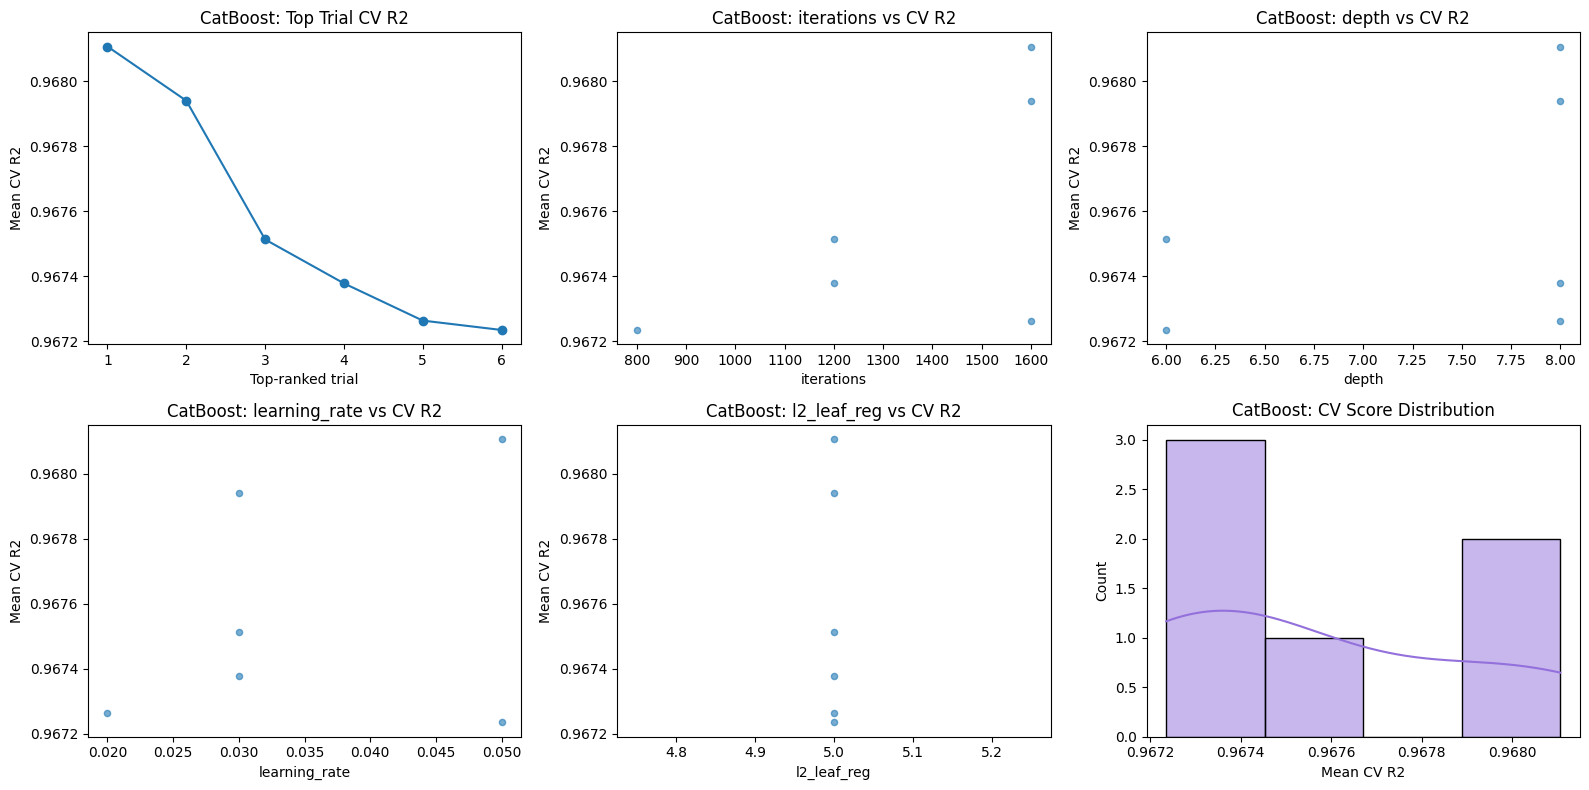

In [52]:
# Hyperparameter search diagnostic plots for selected model
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

top_n = min(12, len(cv_results_df))
axes[0, 0].plot(range(1, top_n + 1), cv_results_df.loc[:top_n - 1, 'mean_test_score'], marker='o')
axes[0, 0].set_title(f'{best_default_name}: Top Trial CV R2')
axes[0, 0].set_xlabel('Top-ranked trial')
axes[0, 0].set_ylabel('Mean CV R2')

param_candidates = list(param_grid.keys())[:4]
for i, p in enumerate(param_candidates, start=1):
    ax = axes.flat[i]
    series = cv_results_df[f'param_{p}']
    x_num = pd.to_numeric(series, errors='coerce')

    if x_num.notna().sum() >= int(0.8 * len(series)):
        ax.scatter(x_num, cv_results_df['mean_test_score'], alpha=0.6, s=20)
        ax.set_xlabel(p)
    else:
        cat = series.astype(str)
        sns.boxplot(x=cat, y=cv_results_df['mean_test_score'], ax=ax)
        ax.tick_params(axis='x', rotation=30)
        ax.set_xlabel(p)

    ax.set_title(f'{best_default_name}: {p} vs CV R2')
    ax.set_ylabel('Mean CV R2')

sns.histplot(cv_results_df['mean_test_score'], kde=True, ax=axes[1, 2], color='mediumpurple')
axes[1, 2].set_title(f'{best_default_name}: CV Score Distribution')
axes[1, 2].set_xlabel('Mean CV R2')

plt.tight_layout()
plt.show()

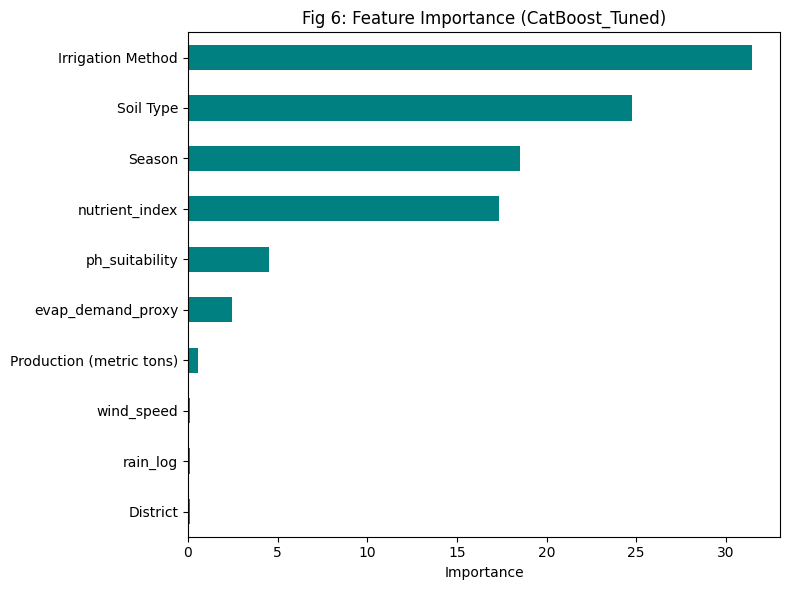

Irrigation Method           31.44800
Soil Type                   24.77114
Season                      18.54126
nutrient_index              17.33695
ph_suitability               4.54330
evap_demand_proxy            2.45807
Production (metric tons)     0.57363
wind_speed                   0.12234
rain_log                     0.11627
District                     0.08904


In [53]:
# Fig 6: Feature importance for tuned final model
if hasattr(best_model, 'feature_importances_'):
    imp_values = best_model.feature_importances_
else:
    perm = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
    imp_values = perm.importances_mean

feat_imp_best = pd.Series(imp_values, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp_best.head(12).sort_values().plot(kind='barh', color='teal')
plt.title(f'Fig 6: Feature Importance ({best_default_name}_Tuned)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(feat_imp_best.head(12).round(5).to_string())

top_features_for_interp = feat_imp_best.head(2).index.tolist()

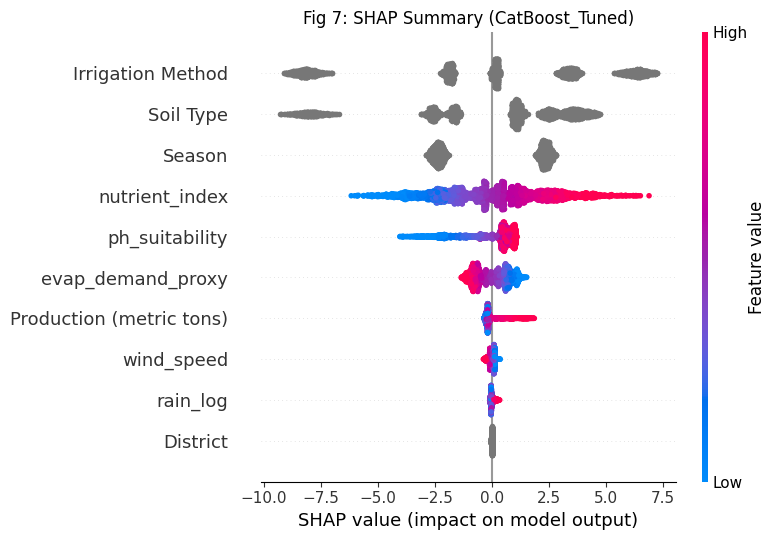

In [54]:
# Fig 7: SHAP summary for tuned final model
sample_n = min(3000, len(X_train))
X_shap = X_train.sample(sample_n, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

plt.figure()
shap.summary_plot(shap_values, X_shap, show=False, max_display=12)
plt.title(f'Fig 7: SHAP Summary ({best_default_name}_Tuned)')
plt.tight_layout()
plt.show()

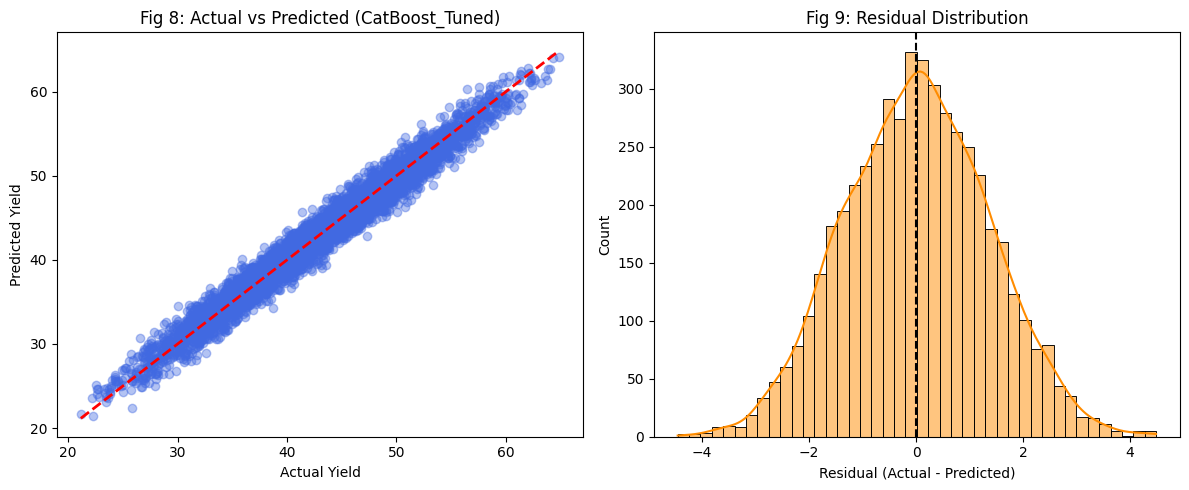

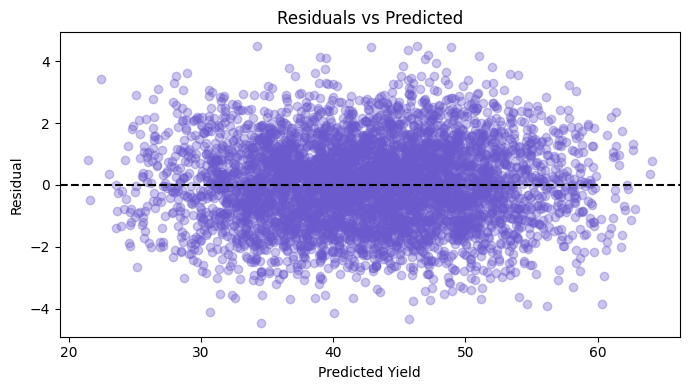

In [55]:
# Fig 8 and Fig 9: evaluation plots for tuned final model
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='royalblue')
line_min = min(y_test.min(), y_pred_best.min())
line_max = max(y_test.max(), y_pred_best.max())
axes[0].plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)
axes[0].set_title(f'Fig 8: Actual vs Predicted ({best_default_name}_Tuned)')
axes[0].set_xlabel('Actual Yield')
axes[0].set_ylabel('Predicted Yield')

sns.histplot(residuals, kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Fig 9: Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_best, residuals, alpha=0.35, color='slateblue')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Yield')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

In [56]:
# Fig 10: PDP removed as requested
pass

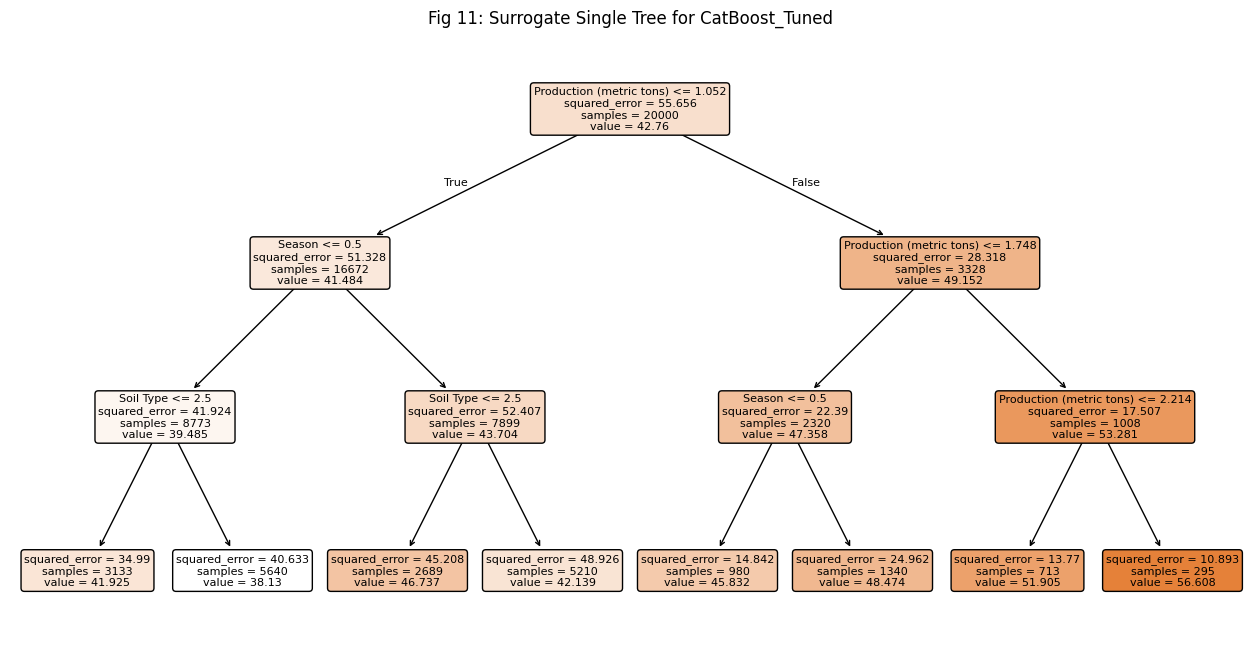

In [59]:
# Fig 11: single-tree surrogate for tuned final model
surrogate_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=80, random_state=42)

# Surrogate tree needs numeric inputs; encode object columns only for this plot.
X_surrogate = X_train.copy()
for col in X_surrogate.select_dtypes(include='object').columns:
    X_surrogate[col] = X_surrogate[col].astype('category').cat.codes

surrogate_tree.fit(X_surrogate, best_model.predict(X_train))

plt.figure(figsize=(16, 8))
plot_tree(
    surrogate_tree,
    feature_names=X_surrogate.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f'Fig 11: Surrogate Single Tree for {best_default_name}_Tuned')
plt.show()